In [2]:
import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from src.data_loader import load_twins_data
from src.preprocessing import preprocess
from src.estimators import (t_learner, t_learner_subgroup_bootstrap)

df = load_twins_data()
df = df.dropna(subset=['tobacco', 'alcohol']).reset_index(drop=True)
df['any_exposure'] = ((df['tobacco'] == 1) | (df['alcohol'] == 1)).astype(int)

X, T, Y, exposure, pair_id = preprocess(df)

# Estimate individual treatment effects
tau = t_learner(X, T, Y)

print(f"Number of tau estimates: {len(tau)}")
print(f"Mean tau (should be close to the ATE): {tau.mean():.4f}")
print(f"Tau range: [{tau.min():.4f}, {tau.max():.4f}]")

Number of tau estimates: 17688
Mean tau (should be close to the ATE): -0.0261
Tau range: [-0.7617, 0.4065]


In [3]:
exposure_arr = np.asarray(exposure)

cate_exposed = tau[exposure_arr == 1].mean()
cate_unexposed = tau[exposure_arr == 0].mean()

print(f"CATE (exposed): {cate_exposed:.4f}")
print(f"CATE (unexposed): {cate_unexposed:.4f}")
print(f"Difference: {cate_exposed - cate_unexposed:.4f}")

CATE (exposed): -0.0278
CATE (unexposed): -0.0256
Difference: -0.0021


In [4]:
results, boot_diff = t_learner_subgroup_bootstrap(X, T, Y, exposure, pair_id, n_boot=500)

for name, (point, lo, hi) in results.items():
    print(f"{name:12s}: {point:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")

exposed     : -0.0278  95% CI [-0.0407, -0.0140]
unexposed   : -0.0256  95% CI [-0.0336, -0.0177]
difference  : -0.0021  95% CI [-0.0176, +0.0145]


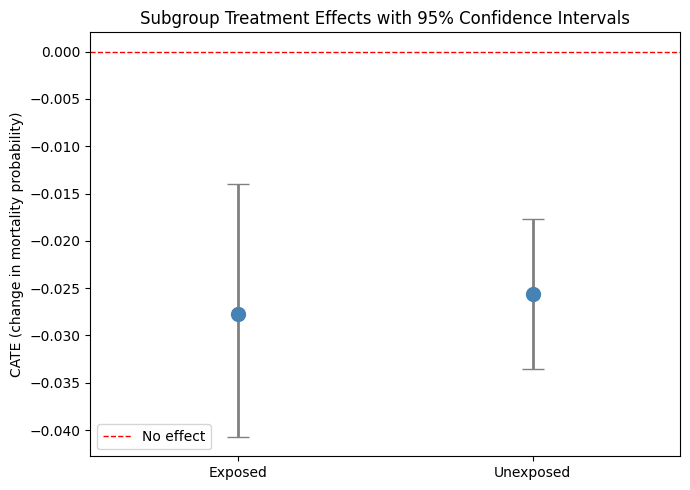

In [5]:
import matplotlib.pyplot as plt

exposed_point, exposed_lo, exposed_hi = results['exposed']
unexposed_point, unexposed_lo, unexposed_hi = results['unexposed']

# X positions for the two subgroups
x_pos = [0, 1]
points = [exposed_point, unexposed_point]

# Error bars: distance from point to each CI bound
# matplotlib wants [lower_distances, upper_distances]
lower_err = [exposed_point - exposed_lo, unexposed_point - unexposed_lo]
upper_err = [exposed_hi - exposed_point, unexposed_hi - unexposed_point]
err = [lower_err, upper_err]

fig, ax = plt.subplots(figsize=(7, 5))

# Plot points with error bars
ax.errorbar(x_pos, points, yerr=err, fmt='o', capsize=8,
            markersize=10, color='steelblue', ecolor='gray', elinewidth=2)

# Reference line at zero (no effect)
ax.axhline(0, color='red', linestyle='dashed', linewidth=1, label='No effect')

# Labels and formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(['Exposed', 'Unexposed'])
ax.set_ylabel('CATE (change in mortality probability)')
ax.set_title('Subgroup Treatment Effects with 95% Confidence Intervals')
ax.set_xlim(-0.5, 1.5)
ax.legend()

plt.tight_layout()
plt.savefig("../figures/subgroup_cate.png", dpi=150, bbox_inches='tight')
plt.show()